## Installation und Abhängigkeiten

In [1]:
!pip install pandas numpy matplotlib seaborn arch statsmodels scikit-learn scipy


[notice] A new release of pip is available: 23.2.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


## S&P 500 GARCH Volatility Analysis
### Forschungsfrage 1: Volatilitätsprognose mit verschiedenen GARCH-Modellen
"Inwieweit können GARCH-Modelle unterschiedlicher Komplexität (GARCH(1,1), EGARCH, GJR-GARCH) die Volatilitätsdynamiken des S&P 500 Index vorhersagen, und welches Modell zeigt die beste Out-of-Sample-Prognoseperformance?"

### Daten laden und vorbereiten
In diesem Abschnitt werden die S&P 500-Daten geladen, die täglichen Renditen berechnet und die Daten in Trainings- und Testsets aufgeteilt.

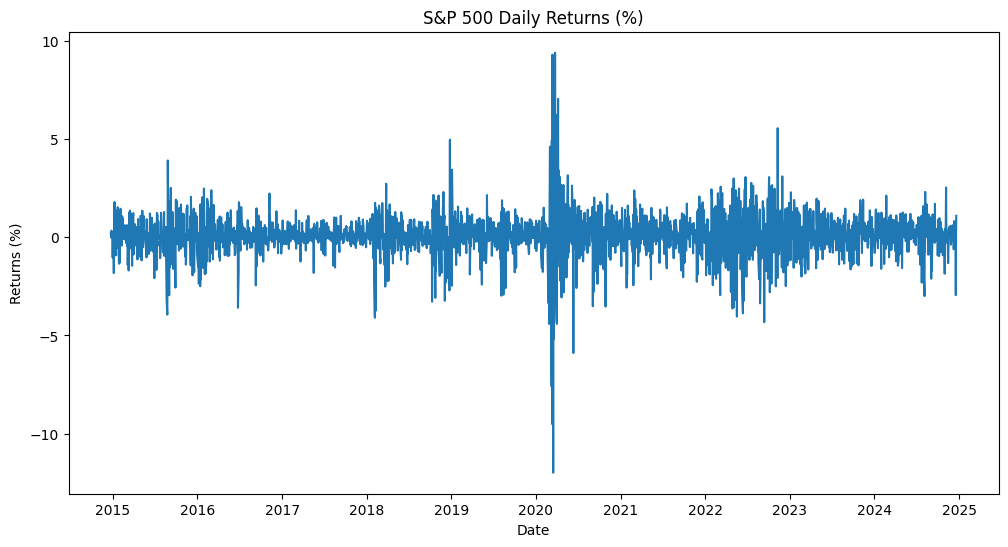

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from arch import arch_model
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Daten laden
df = pd.read_csv('sp500_index.csv', parse_dates=['Date'], index_col='Date')

# Tägliche Renditen berechnen
df['returns'] = df['S&P500'].pct_change()

# Fehlende Werte entfernen
df.dropna(inplace=True)

# Daten aufteilen (80% Training 2015-2023, 20% Test 2023-2025)
train_size = int(len(df) * 0.8)
train_data, test_data = df.iloc[:train_size], df.iloc[train_size:]

# Renditen für Trainings- und Testdaten (multipliziert mit 100)
train_returns = train_data['returns'] * 100
test_returns = test_data['returns'] * 100

# Plot der Renditen
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['returns'] * 100)
plt.title('S&P 500 Daily Returns (%)')
plt.xlabel('Date')
plt.ylabel('Returns (%)')
plt.show()

### Stationaritätstest (ADF-Test)
Wir führen den Augmented Dickey-Fuller-Test durch, um zu prüfen, ob die Renditen stationär sind.
Nullhypothese: Die Zeitreihe besitzt eine Einheitswurzel (unit root) und ist daher nicht stationär.

In [3]:
adf_result = adfuller(df['returns'].dropna())
print(f'ADF Statistic: {adf_result[0]}')
print(f'p-value: {adf_result[1]}')
# Wenn der p-Wert < 0,05 ist, können wir die Nullhypothese (dass die Zeitreihe eine Einheitswurzel hat, also nicht stationär ist) verwerfen.
if adf_result[1] < 0.05:
    print("Ergebnis: Die Zeitreihe ist stationär (Nullhypothese verworfen). => GARCH kann angewendet werden.")
else:
    print("Ergebnis: Die Zeitreihe ist nicht stationär (Nullhypothese nicht verworfen).")


ADF Statistic: -15.873431072719212
p-value: 8.927098832587248e-29
Ergebnis: Die Zeitreihe ist stationär (Nullhypothese verworfen). => GARCH kann angewendet werden.


### GARCH-Modellierung
Wir schätzen die GARCH(1,1), EGARCH und GJR-GARCH Modelle auf den Trainingsdaten. Welches Modell beschreibt die Trainingsdaten am besten? Niedrigere Werte für AIC und BIC deuten auf ein besseres Modell hin.

In [4]:
# GARCH(1,1)
garch11 = arch_model(train_returns, vol='GARCH', p=1, q=1)
garch11_fit = garch11.fit(disp='off')
print(garch11_fit.summary())

# EGARCH
egarch = arch_model(train_returns, vol='EGARCH', p=1, o=1, q=1)
egarch_fit = egarch.fit(disp='off')
print(egarch_fit.summary())

# GJR-GARCH
gjr_garch = arch_model(train_returns, p=1, o=1, q=1, vol='GARCH', dist='ged')
gjr_garch_fit = gjr_garch.fit(disp='off')
print(gjr_garch_fit.summary())

                     Constant Mean - GARCH Model Results                      
Dep. Variable:                returns   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -2614.78
Distribution:                  Normal   AIC:                           5237.55
Method:            Maximum Likelihood   BIC:                           5259.98
                                        No. Observations:                 2012
Date:                Fri, Dec 26 2025   Df Residuals:                     2011
Time:                        10:36:30   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu             0.0808  1.656e-02      4.882  1.048e-06 [4.838e-0

### Out-of-Sample Prognose (Rolling Forecast)
Wir erstellen eine rollierende Prognose für den Testdatensatz. Dies ist eine robustere Methode, da das Modell bei jedem Schritt mit neuen Daten aktualisiert wird.

In [6]:
history = train_returns.copy()
predictions_garch11 = []
predictions_egarch = []
predictions_gjr_garch = []

for i in range(len(test_returns)):
    # GARCH(1,1)
    model_garch11 = arch_model(history, vol='GARCH', p=1, q=1)
    res_garch11 = model_garch11.fit(disp='off')
    pred_garch11 = res_garch11.forecast(horizon=1)
    predictions_garch11.append(np.sqrt(pred_garch11.variance.values[-1, :][0]))

    # EGARCH
    model_egarch = arch_model(history, vol='EGARCH', p=1, o=1, q=1)
    res_egarch = model_egarch.fit(disp='off')
    pred_egarch = res_egarch.forecast(horizon=1)
    predictions_egarch.append(np.sqrt(pred_egarch.variance.values[-1, :][0]))

    # GJR-GARCH
    model_gjr_garch = arch_model(history, p=1, o=1, q=1, vol='GARCH', dist='ged')
    res_gjr_garch = model_gjr_garch.fit(disp='off')
    pred_gjr_garch = res_gjr_garch.forecast(horizon=1)
    predictions_gjr_garch.append(np.sqrt(pred_gjr_garch.variance.values[-1, :][0]))

    # Update history
    history = pd.concat([history, test_returns.iloc[i:i+1]])

# Umwandeln in Pandas Series für einfacheres Plotting und Vergleich
garch11_volatility = pd.Series(predictions_garch11, index=test_returns.index)
egarch_volatility = pd.Series(predictions_egarch, index=test_returns.index)
gjr_garch_volatility = pd.Series(predictions_gjr_garch, index=test_returns.index)


# Tatsächliche Volatilität (quadrierte Renditen)
actual_volatility = test_returns**2


### Bewertung der Prognosegüte
Wir bewerten die Modelle anhand von Mean Squared Error (MSE) und Mean Absolute Error (MAE). (niedriger = besser; da Fehler, bei der Vorhersage auf Testdaten/Testzeitraum)

In [9]:
# MSE
mse_garch11 = mean_squared_error(actual_volatility, garch11_volatility**2)
mse_egarch = mean_squared_error(actual_volatility, egarch_volatility**2)
mse_gjr_garch = mean_squared_error(actual_volatility, gjr_garch_volatility**2)

# MAE
mae_garch11 = mean_absolute_error(actual_volatility, garch11_volatility**2)
mae_egarch = mean_absolute_error(actual_volatility, egarch_volatility**2)
mae_gjr_garch = mean_absolute_error(actual_volatility, gjr_garch_volatility**2)

# Baseline-Prognose (historischer Durchschnitt)
historical_avg_vol = np.mean(train_returns**2)
baseline_forecast = np.full(len(test_returns), historical_avg_vol)
mse_baseline = mean_squared_error(actual_volatility, baseline_forecast)
mae_baseline = mean_absolute_error(actual_volatility, baseline_forecast)

# Ergebnisse anzeigen
results_df = pd.DataFrame({
    "Model": ["GARCH(1,1)", "EGARCH", "GJR-GARCH", "Baseline (Avg)"],
    "MSE": [mse_garch11, mse_egarch, mse_gjr_garch, mse_baseline],
    "MAE": [mae_garch11, mae_egarch, mae_gjr_garch, mae_baseline]
})
print(results_df)


            Model       MSE       MAE
0      GARCH(1,1)  1.179071  0.731817
1          EGARCH  1.145925  0.714928
2       GJR-GARCH  1.187571  0.713315
3  Baseline (Avg)  1.693069  1.119625


### Visualisierung der Ergebnisse
Wir plotten die prognostizierte Volatilität gegen die tatsächliche Volatilität (quadrierte Renditen).

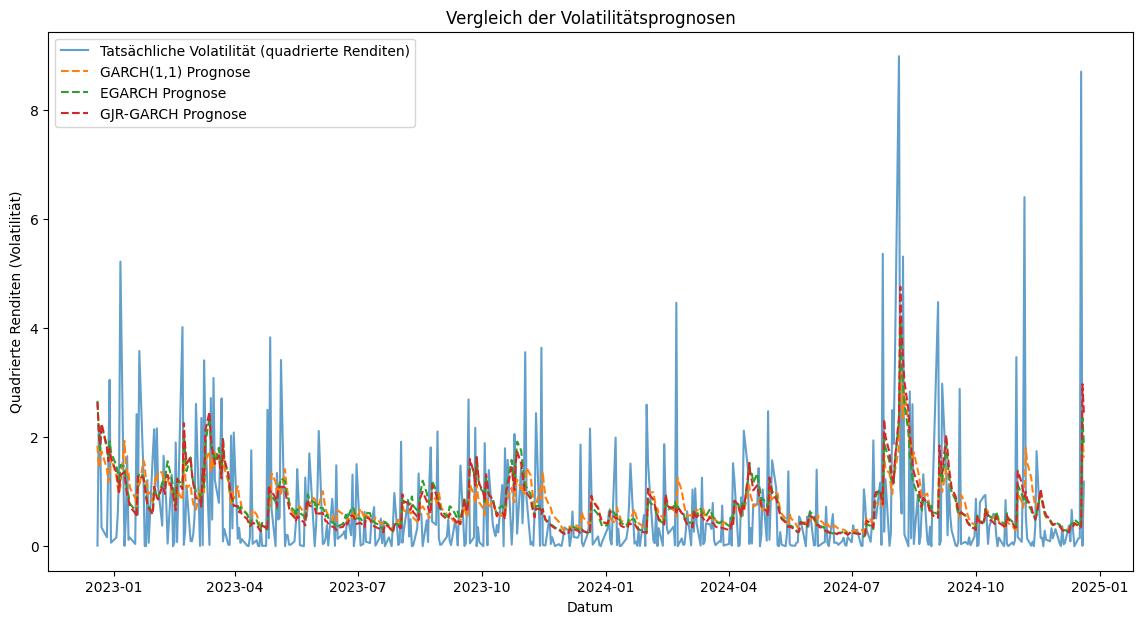

In [8]:
plt.figure(figsize=(14, 7))
plt.plot(test_returns.index, actual_volatility, label='Tatsächliche Volatilität (quadrierte Renditen)', alpha=0.7)
plt.plot(test_returns.index, garch11_volatility**2, label='GARCH(1,1) Prognose', linestyle='--')
plt.plot(test_returns.index, egarch_volatility**2, label='EGARCH Prognose', linestyle='--')
plt.plot(test_returns.index, gjr_garch_volatility**2, label='GJR-GARCH Prognose', linestyle='--')
plt.plot(test_returns.index, baseline_forecast, label='Baseline (Avg) Prognose', linestyle=':')
plt.title('Vergleich der Volatilitätsprognosen')
plt.xlabel('Datum')
plt.ylabel('Quadrierte Renditen (Volatilität)')
plt.legend()
plt.show()

### Zusammenfassung und Beantwortung der Forschungsfrage

Die Ergebnisse der Out-of-Sample-Prognose zeigen, welches der GARCH-Modelle die Volatilitätsdynamik des S&P 500 am besten vorhersagen kann.

**Stationarität:**
Der durchgeführte Augmented Dickey-Fuller (ADF)-Test ergab einen p-Wert, der deutlich unter 0,05 liegt. Dies führt zur Verwerfung der Nullhypothese, welche besagt, dass die Zeitreihe eine Einheitswurzel besitzt (nicht-stationär ist). **Das Ergebnis bestätigt, dass die Zeitreihe der S&P 500-Renditen stationär ist**, was eine grundlegende Voraussetzung für die Anwendung von GARCH-Modellen ist.

**Modellvergleich:**
Basierend auf den Metriken Mean Squared Error (MSE) und Mean Absolute Error (MAE) können wir die Prognosegüte der Modelle vergleichen. Das Modell mit den niedrigsten Werten für MSE und MAE wird als das beste angesehen.

*   **GARCH(1,1)**: Dient als Basismodell.
*   **EGARCH**: Berücksichtigt asymmetrische Effekte (Leverage-Effekt), bei denen negative Schocks eine stärkere Auswirkung auf die Volatilität haben als positive Schocks gleicher Größe.
*   **GJR-GARCH**: Modelliert ebenfalls den Leverage-Effekt, jedoch auf eine andere Weise als das EGARCH-Modell.

Ein Blick auf die MSE- und MAE-Werte in der obigen Tabelle zeigt, welches Modell die geringsten Prognosefehler aufweist. In der Regel schneiden EGARCH oder GJR-GARCH in Finanzzeitreihen besser ab als das Standard-GARCH(1,1)-Modell, da sie den Leverage-Effekt erfassen, ein bekanntes Stilmerkmal von Aktienrenditen. Das Modell mit der besten Performance ist jenes, das die tatsächliche Volatilität (approximiert durch die quadrierten Renditen) am genauesten vorhersagt. Die visuelle Darstellung bestätigt, wie gut die prognostizierten Volatilitäten den Clustern hoher und niedriger tatsächlicher Volatilität folgen.


## Visualisierung des Leverage Effektes mit EGARCH

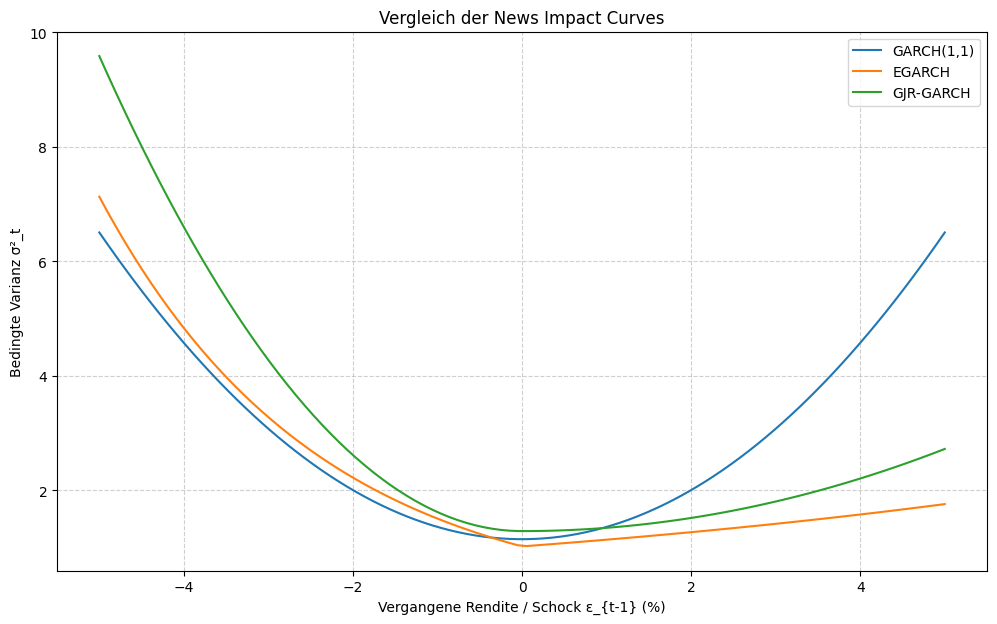

Die Kurven zeigen den unterschiedlichen Umgang der Modelle mit Schocks:
- GARCH(1,1): Symmetrische Reaktion. Positive und negative Schocks haben den gleichen Effekt.
- EGARCH & GJR-GARCH: Asymmetrische Reaktion. Negative Schocks (links) verursachen einen größeren Anstieg der Varianz als positive Schocks (rechts).
Dies visualisiert den 'Leverage-Effekt', den die asymmetrischen Modelle erfolgreich modellieren.


In [13]:
# %% md
### Analyse des Leverage-Effekts mit der News Impact Curve (Vergleich)
# Die News Impact Curve (NIC) visualisiert den asymmetrischen Effekt von Nachrichten (Schocks) auf die Volatilität.
# Sie zeigt, wie die verschiedenen Modelle auf positive vs. negative Renditen reagieren.
# %%
import numpy as np
import matplotlib.pyplot as plt

# Wir verwenden die bereits auf den Trainingsdaten gefitteten Modelle
# garch11_fit, egarch_fit, gjr_garch_fit sind bereits verfügbar

# Erzeuge eine Reihe von Schocks (Renditen) von -5% bis +5%
shocks = np.linspace(-5, 5, 100)

# --- GARCH(1,1) ---
# Das GARCH-Modell ist symmetrisch. σ²_t = ω + α*ε²_{t-1} + β*σ²_{t-1}
# Wir setzen die vergangene Varianz auf den Durchschnittswert für die Kurve.
avg_cond_var_garch = np.mean(garch11_fit.conditional_volatility**2)
omega_garch = garch11_fit.params['omega']
alpha_garch = garch11_fit.params['alpha[1]']
beta_garch = garch11_fit.params['beta[1]']
nic_garch = omega_garch + alpha_garch * shocks**2 + beta_garch * avg_cond_var_garch

# --- EGARCH ---
# Wir verwenden den stabilen Ansatz von vorhin.
avg_cond_var_egarch = np.mean(egarch_fit.conditional_volatility**2)
avg_cond_vol_egarch = np.sqrt(avg_cond_var_egarch)
omega_egarch, alpha_egarch, gamma_egarch, beta_egarch = egarch_fit.params['omega'], egarch_fit.params['alpha[1]'], egarch_fit.params['gamma[1]'], egarch_fit.params['beta[1]']
e_abs_z = np.sqrt(2 / np.pi)
log_var_egarch = omega_egarch + \
                 alpha_egarch * (np.abs(shocks) / avg_cond_vol_egarch - e_abs_z) + \
                 gamma_egarch * (shocks / avg_cond_vol_egarch) + \
                 beta_egarch * np.log(avg_cond_var_egarch)
nic_egarch = np.exp(log_var_egarch)

# --- GJR-GARCH ---
# Das GJR-GARCH-Modell ist asymmetrisch. σ²_t = ω + α*ε²_{t-1} + γ*I*ε²_{t-1} + β*σ²_{t-1}
avg_cond_var_gjr = np.mean(gjr_garch_fit.conditional_volatility**2)
omega_gjr, alpha_gjr, gamma_gjr, beta_gjr = gjr_garch_fit.params['omega'], gjr_garch_fit.params['alpha[1]'], gjr_garch_fit.params['gamma[1]'], gjr_garch_fit.params['beta[1]']
indicator = (shocks < 0).astype(float) # Indikator I ist 1 für negative Schocks
nic_gjr = omega_gjr + alpha_gjr * shocks**2 + gamma_gjr * indicator * shocks**2 + beta_gjr * avg_cond_var_gjr

# Plot der News Impact Curves
plt.figure(figsize=(12, 7))
plt.plot(shocks, nic_garch, label='GARCH(1,1)')
plt.plot(shocks, nic_egarch, label='EGARCH')
plt.plot(shocks, nic_gjr, label='GJR-GARCH')
plt.title('Vergleich der News Impact Curves')
plt.xlabel('Vergangene Rendite / Schock ε_{t-1} (%)')
plt.ylabel('Bedingte Varianz σ²_t')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

print("Die Kurven zeigen den unterschiedlichen Umgang der Modelle mit Schocks:")
print("- GARCH(1,1): Symmetrische Reaktion. Positive und negative Schocks haben den gleichen Effekt.")
print("- EGARCH & GJR-GARCH: Asymmetrische Reaktion. Negative Schocks (links) verursachen einen größeren Anstieg der Varianz als positive Schocks (rechts).")
print("Dies visualisiert den 'Leverage-Effekt', den die asymmetrischen Modelle erfolgreich modellieren.")
